In [166]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [168]:
img = cv2.imread('hist1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Hist Equilization on Single Channel Image

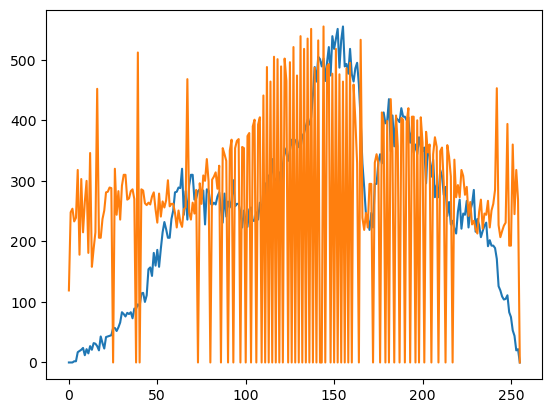

In [171]:
# Original image Histogram(Single Channel image)
hist = cv2.calcHist([img], [0], None, [256], [0,255])
plt.plot(hist)

# Histogram Euilasation
hist_eui = cv2.equalizeHist(img)
hist = cv2.calcHist([hist_eui], [0], None, [256], [0,255])
plt.plot(hist)

# Histogram Euilasation Using CLAHE
clahe = cv2.createCLAHE(clipLimit = 3)
final_img = clahe.apply(img)
# hist = cv2.calcHist([hist_eui], [0], None, [256], [0,255])
# plt.plot(hist)

In [173]:

cv2.imshow('Original', img)
cv2.imshow('Histogram Equilization', hist_eui)
cv2.imshow('CLAHE Equilization', final_img)


if cv2.waitKey(0) & 0xFF == ord('q'):
    cv2.destroyAllWindows()

# Hist Equilization on Coloured Image

In [149]:
col_img = cv2.imread('hist2.jpg')
img = cv2.resize(img, None, fx = 3., fy = 3.)

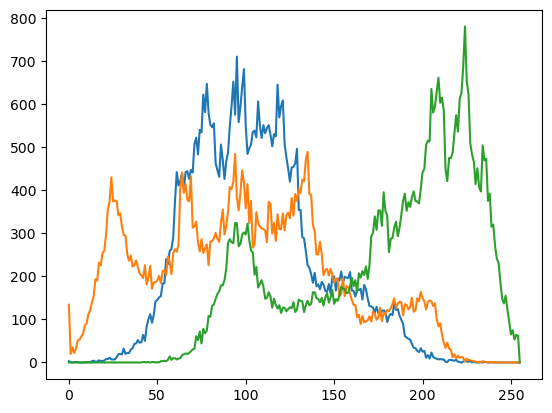

In [123]:
# Spliting image Channels
b, g, r = cv2.split(col_img)

hist = cv2.calcHist([b], [0], None, [256], [0,255])
plt.plot(hist)
hist = cv2.calcHist([g], [0], None, [256], [0,255])
plt.plot(hist)
hist = cv2.calcHist([r], [0], None, [256], [0,255])
plt.plot(hist)

In [155]:
# Performing Histogram Eqilasation on all 3 Channels
b_hist_equi = cv2.equalizeHist(b)
g_hist_equi = cv2.equalizeHist(g)
r_hist_equi = cv2.equalizeHist(r)

new_col_img = cv2.merge((b_hist_equi, g_hist_equi, r_hist_equi))

In [124]:
bgr_to_hsv = cv2.cvtColor(col_img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(bgr_to_hsv)

h_change, s_change, v_change = np.copy(h),np.copy(s),np.copy(v)

In [125]:
# Performing Histogram Eqilasation on Value Channel
v_change_hist_eui = cv2.equalizeHist(v_change)
merged_v_change = cv2.merge((h,s,v_change_hist_eui))

hsv_to_bgr_v_change = cv2.cvtColor(merged_v_change, cv2.COLOR_HSV2BGR)

In [126]:
# Performing Histogram Eqilasation on Saturation Channel
h_change_hist_eui = cv2.equalizeHist(h_change)
merged_h_change = cv2.merge((h_change_hist_eui,s,v))

hsv_to_bgr_h_change = cv2.cvtColor(merged_h_change, cv2.COLOR_HSV2BGR)

In [127]:
# Performing Histogram Eqilasation on Heu Channel
s_change_hist_eui = cv2.equalizeHist(s_change)
merged_s_change = cv2.merge((h,s_change_hist_eui,v))

hsv_to_bgr_s_change = cv2.cvtColor(merged_s_change, cv2.COLOR_HSV2BGR)

In [157]:
cv2.imshow('Original', col_img)
cv2.imshow('V_Changed', hsv_to_bgr_v_change)
cv2.imshow('H_Changed', hsv_to_bgr_h_change)
cv2.imshow('S_Changed', hsv_to_bgr_s_change)
cv2.imshow('Original_Changed', new_col_img)

if cv2.waitKey(0) & 0xFF == ord('q'):
    cv2.destroyAllWindows()